# Sesión 12: de la descomposición espectral a PCA

**Curso:** Estadística Multivariable Aplicada para Ciencia de Datos  
**Continuidad:** esta sesión retoma la interpretación geométrica de autovalores y autovectores trabajada en la sesión anterior y avanza hacia la construcción formal de PCA.  
**Objetivo:** entender, de forma rigurosa y aplicada, cómo la descomposición espectral de una matriz de covarianza conduce a las direcciones principales, a la varianza explicada y finalmente al algoritmo de Análisis de Componentes Principales (PCA).

## Ruta de la sesión

1. Descomposición espectral de matrices simétricas.
2. Varianza explicada.
3. Direcciones principales como problema de optimización.
4. Construcción paso a paso de PCA.
5. Ejemplos, simulaciones y visualizaciones.
6. Ejercicios para resolver en clase.

## Idea central

Si $X \in \mathbb{R}^p$ es un vector aleatorio con matriz de covarianza $\Sigma$, entonces los autovectores de $\Sigma$ indican **direcciones ortogonales especiales** del espacio y los autovalores indican **cuánta variabilidad hay en cada una de esas direcciones**.

PCA organiza esas direcciones de mayor a menor variabilidad y permite:
- resumir información,
- reducir dimensión,
- eliminar redundancia lineal,
- construir nuevas variables no correlacionadas.

## Nota pedagógica

En todo el notebook trabajaremos con:
- variables centradas cuando sea necesario,
- matrices simétricas,
- notación simple y explícita,
- ejemplos numéricos y simulaciones.

Todo el contenido usa únicamente $ y $ para las expresiones matemáticas.

In [1]:
# @title Importaciones
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from numpy.linalg import eigh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (7, 5)
plt.rcParams["axes.grid"] = True

## 1. Puente con la sesión anterior

En la sesión previa estudiamos que, para una matriz cuadrada $A$, un autovector $v$ asociado a un autovalor $\lambda$ satisface

$$
A v = \lambda v.
$$

Cuando $A = \Sigma$, la matriz de covarianza, esta ecuación deja de ser solo álgebra y pasa a tener significado estadístico:

- $v$ define una dirección en el espacio,
- $\lambda$ mide la varianza asociada a esa dirección.

Más precisamente, si $a$ es un vector unitario, la variable proyectada $a^T X$ tiene varianza

$$
\mathrm{Var}(a^T X) = a^T \Sigma a.
$$

PCA surge al preguntarnos:

**¿cuál es la dirección $a$ en la que los datos varían más?**

La respuesta llevará directamente al mayor autovalor y a su autovector asociado.

## 2. Descomposición espectral de una matriz simétrica

### Definición

Sea $\Sigma$ una matriz simétrica de tamaño $p \times p$. Entonces existe una matriz ortogonal $Q$ y una matriz diagonal $\Lambda$ tales que

$$
\Sigma = Q \Lambda Q^T,
$$

donde:

- $Q = [q_1,\dots,q_p]$ contiene autovectores ortonormales,
- $\Lambda = \mathrm{diag}(\lambda_1,\dots,\lambda_p)$ contiene los autovalores.

Si además $\Sigma$ es matriz de covarianza, entonces:

- $\Sigma$ es simétrica,
- $\Sigma$ es semidefinida positiva,
- por tanto $\lambda_j \ge 0$ para todo $j$.

### Interpretación

La descomposición espectral dice que la covarianza total puede escribirse como

$$
\Sigma = \lambda_1 q_1 q_1^T + \lambda_2 q_2 q_2^T + \cdots + \lambda_p q_p q_p^T.
$$

Esto significa que la variabilidad total se reparte en direcciones ortogonales, y cada dirección aporta una cantidad de varianza dada por su autovalor.

In [2]:
# @title Ejemplo numérico simple de descomposición espectral
Sigma = np.array([
    [4.0, 2.4],
    [2.4, 2.0]
])

eigvals, eigvecs = eigh(Sigma)

# Ordenamos de mayor a menor
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

print("Sigma =")
print(Sigma)
print("\nAutovalores (de mayor a menor) =")
print(eigvals)
print("\nAutovectores (columnas) =")
print(eigvecs)

Sigma_reconstruida = eigvecs @ np.diag(eigvals) @ eigvecs.T
print("\nReconstrucción Q Λ Q^T =")
print(Sigma_reconstruida)

Sigma =
[[4.  2.4]
 [2.4 2. ]]

Autovalores (de mayor a menor) =
[5.6 0.4]

Autovectores (columnas) =
[[-0.8321  0.5547]
 [-0.5547 -0.8321]]

Reconstrucción Q Λ Q^T =
[[4.  2.4]
 [2.4 2. ]]


### Lectura del ejemplo

En este ejemplo:

- el autovalor más grande representa la dirección de máxima dispersión,
- el segundo autovalor representa la dirección ortogonal restante,
- la reconstrucción $Q \Lambda Q^T$ devuelve exactamente la matriz original salvo errores numéricos de redondeo.

Eso muestra que la matriz de covarianza queda completamente descrita por sus autovalores y autovectores.

In [3]:
# @title Funciones auxiliares para gráficos
def simular_normal(mu, Sigma, n=400, seed=123):
    rng = np.random.default_rng(seed)
    return rng.multivariate_normal(mean=mu, cov=Sigma, size=n)

def dibujar_autodirecciones(ax, Sigma, centro=np.zeros(2), scale=2.5, color1="crimson", color2="darkgreen"):
    vals, vecs = eigh(Sigma)
    idx = np.argsort(vals)[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]

    for j, color in enumerate([color1, color2]):
        v = vecs[:, j]
        l = vals[j]
        extremo = centro + scale * np.sqrt(l) * v
        ax.plot([centro[0], extremo[0]], [centro[1], extremo[1]], color=color, lw=3)
        ax.text(extremo[0], extremo[1], f"PC{j+1}", fontsize=11, weight="bold")

def plot_nube_y_direcciones(X, Sigma, titulo):
    fig, ax = plt.subplots()
    ax.scatter(X[:, 0], X[:, 1], alpha=0.45, s=18)
    dibujar_autodirecciones(ax, Sigma)
    ax.axhline(0, color="gray", lw=1)
    ax.axvline(0, color="gray", lw=1)
    ax.set_title(titulo)
    ax.set_xlabel("$X_1$")
    ax.set_ylabel("$X_2$")
    ax.set_aspect("equal")
    plt.show()

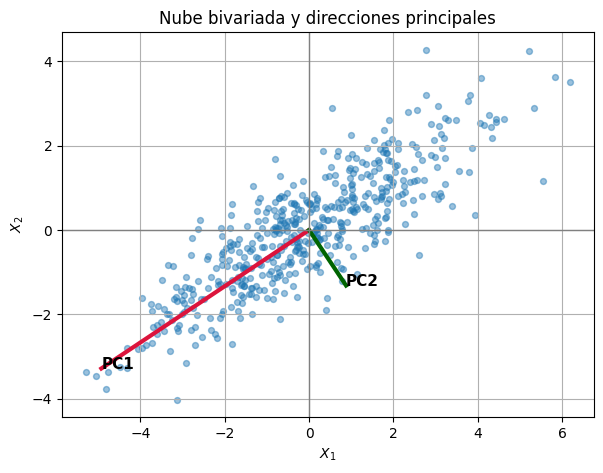

In [4]:
# @title Geometría: la nube y sus direcciones principales
X = simular_normal(mu=[0, 0], Sigma=Sigma, n=500, seed=3)
plot_nube_y_direcciones(X, Sigma, "Nube bivariada y direcciones principales")

## 3. Geometría: por qué los autovectores son direcciones principales

Si la nube de puntos es alargada en cierta dirección, esa es la dirección donde la proyección tiene mayor varianza.

Sea $a$ un vector unitario, es decir, $a^T a = 1$. La proyección de $X$ sobre $a$ es

$$
Y_a = a^T X.
$$

Su varianza es

$$
\mathrm{Var}(Y_a) = a^T \Sigma a.
$$

Entonces el problema geométrico-natural es:

$$
\max_{a^T a = 1} a^T \Sigma a.
$$

La solución de este problema es el autovector asociado al mayor autovalor de $\Sigma$.

### Conclusión importante

- la **primera dirección principal** es el autovector del mayor autovalor;
- la **segunda dirección principal** es el autovector del segundo mayor autovalor, restringido a ser ortogonal a la primera;
- y así sucesivamente.

Por eso PCA no es una receta arbitraria: nace de un problema de optimización muy claro.

## 4. Demostración paso a paso de la primera dirección principal

### Objetivo del problema

Sea $X \in \mathbb{R}^p$ un vector aleatorio con matriz de covarianzas $\Sigma$.

Queremos encontrar una dirección unitaria $a \in \mathbb{R}^p$ tal que la proyección escalar $a^T X$ tenga la mayor varianza posible.

Ya sabemos que

$$
\mathrm{Var}(a^T X) = a^T \Sigma a.
$$

Por tanto, el problema consiste en maximizar

$$
a^T \Sigma a
$$

sujeto a la restricción

$$
a^T a = 1.
$$

La restricción $a^T a = 1$ significa que $a$ debe ser un vector unitario. Esta condición es necesaria porque, si no la impusiéramos, podríamos multiplicar $a$ por una constante grande y hacer arbitrariamente grande el valor de $a^T \Sigma a$. Es decir, sin restricción, el problema no tendría sentido geométrico.

---

### Paso 1. Reconocer que es un problema de optimización con restricción

Tenemos una función objetivo

$$
f(a) = a^T \Sigma a
$$

y una restricción

$$
g(a) = a^T a - 1 = 0.
$$

Este es un problema estándar de optimización restringida. Para resolverlo, usamos el método de multiplicadores de Lagrange.

---

### Paso 2. Construir la función de Lagrange

Definimos la función de Lagrange por

$$
\mathcal{L}(a,\lambda) = a^T \Sigma a - \lambda(a^T a - 1).
$$

Aquí:

- $a$ es el vector que queremos encontrar,
- $\lambda$ es el multiplicador de Lagrange,
- el término $-\lambda(a^T a - 1)$ incorpora la restricción dentro del problema de optimización.

La idea es que los puntos críticos del problema restringido se obtienen buscando los puntos críticos de $\mathcal{L}$.

---

### Paso 3. Derivar respecto del vector $a$

Ahora debemos derivar $\mathcal{L}(a,\lambda)$ respecto de $a$.

Para hacerlo con claridad, usamos dos hechos importantes.

#### Hecho 1. Derivada de una forma cuadrática

Queremos justificar con detalle por qué, si $A$ es una matriz constante de tamaño $p \times p$ y $a \in \mathbb{R}^p$, entonces

$$
\frac{\partial}{\partial a}(a^T A a) = (A + A^T)a.
$$

Para entenderlo bien, empecemos escribiendo la expresión en componentes.

Sea

$$
a =
\begin{pmatrix}
a_1\\
a_2\\
\vdots\\
a_p
\end{pmatrix},
\qquad
A = (A_{ij})_{i,j=1}^p.
$$

Entonces

$$
a^T A a
=
\sum_{i=1}^p \sum_{j=1}^p a_i A_{ij} a_j.
$$

Esto es un escalar. Ahora queremos derivarlo respecto del vector $a$, es decir, respecto de cada componente $a_k$.

---

##### Derivada respecto de una componente $a_k$

Tomemos

$$
f(a)=a^T A a=\sum_{i=1}^p \sum_{j=1}^p a_i A_{ij} a_j.
$$

Derivemos respecto de $a_k$:

$$
\frac{\partial f}{\partial a_k}
=
\frac{\partial}{\partial a_k}
\left(
\sum_{i=1}^p \sum_{j=1}^p a_i A_{ij} a_j
\right).
$$

Aquí hay que notar algo importante:

- $a_k$ puede aparecer como $a_i$ cuando $i=k$,
- y también puede aparecer como $a_j$ cuando $j=k$.

Por tanto, aparecen dos contribuciones.

La primera contribución viene de los términos donde $i=k$:

$$
\sum_{j=1}^p A_{kj} a_j.
$$

La segunda contribución viene de los términos donde $j=k$:

$$
\sum_{i=1}^p a_i A_{ik}.
$$

Entonces,

$$
\frac{\partial f}{\partial a_k}
=
\sum_{j=1}^p A_{kj} a_j
+
\sum_{i=1}^p a_i A_{ik}.
$$

Ahora observemos que

$$
\sum_{j=1}^p A_{kj} a_j
$$

es la componente $k$ del vector $Aa$, y que

$$
\sum_{i=1}^p a_i A_{ik}
=
\sum_{i=1}^p (A^T)_{ki} a_i
$$

es la componente $k$ del vector $A^T a$.

Por tanto, la componente $k$ del gradiente es

$$
\frac{\partial f}{\partial a_k}
=
(Aa)_k + (A^T a)_k.
$$

Como esto vale para todo $k=1,\dots,p$, concluimos que

$$
\frac{\partial}{\partial a}(a^T A a) = Aa + A^T a = (A+A^T)a.
$$

---

##### Caso particular: cuando $A$ es simétrica

Si $A$ es simétrica, entonces

$$
A^T = A.
$$

Sustituyendo en la expresión anterior,

$$
\frac{\partial}{\partial a}(a^T A a)
=
(A+A^T)a
=
(A+A)a
=
2Aa.
$$

Así obtenemos el resultado:

$$
\frac{\partial}{\partial a}(a^T A a)=2Aa
\qquad \text{si } A=A^T.
$$

---

##### Ejemplo pequeño en dimensión 2

Tomemos

$$
A=
\begin{pmatrix}
1 & 2\\
3 & 4
\end{pmatrix},
\qquad
a=
\begin{pmatrix}
x\\
y
\end{pmatrix}.
$$

Entonces

$$
a^T A a
=
\begin{pmatrix}
x & y
\end{pmatrix}
\begin{pmatrix}
1 & 2\\
3 & 4
\end{pmatrix}
\begin{pmatrix}
x\\
y
\end{pmatrix}.
$$

Primero calculamos

$$
Aa=
\begin{pmatrix}
1 & 2\\
3 & 4
\end{pmatrix}
\begin{pmatrix}
x\\
y
\end{pmatrix}
=
\begin{pmatrix}
x+2y\\
3x+4y
\end{pmatrix}.
$$

Luego,

$$
a^T A a
=
\begin{pmatrix}
x & y
\end{pmatrix}
\begin{pmatrix}
x+2y\\
3x+4y
\end{pmatrix}
=
x(x+2y)+y(3x+4y).
$$

Por tanto,

$$
a^T A a = x^2 + 5xy + 4y^2.
$$

Ahora derivamos directamente respecto de $x$ y $y$:

$$
\frac{\partial}{\partial x}(x^2+5xy+4y^2)=2x+5y,
$$

$$
\frac{\partial}{\partial y}(x^2+5xy+4y^2)=5x+8y.
$$

Así, el gradiente es

$$
\nabla (a^T A a)=
\begin{pmatrix}
2x+5y\\
5x+8y
\end{pmatrix}.
$$

Ahora verifiquemos la fórmula $(A+A^T)a$.

Tenemos

$$
A^T=
\begin{pmatrix}
1 & 3\\
2 & 4
\end{pmatrix},
$$

de modo que

$$
A+A^T=
\begin{pmatrix}
2 & 5\\
5 & 8
\end{pmatrix}.
$$

Entonces

$$
(A+A^T)a
=
\begin{pmatrix}
2 & 5\\
5 & 8
\end{pmatrix}
\begin{pmatrix}
x\\
y
\end{pmatrix}
=
\begin{pmatrix}
2x+5y\\
5x+8y
\end{pmatrix},
$$

que coincide exactamente con la derivada calculada a mano.

---

##### Aplicación al caso de PCA

En PCA trabajamos con la matriz de covarianzas $\Sigma$, y una matriz de covarianzas siempre es simétrica. Por tanto,

$$
\frac{\partial}{\partial a}(a^T \Sigma a)=2\Sigma a.
$$

Este es el resultado que usamos en la demostración de la primera dirección principal.

---

#### Hecho 2. Derivada de la norma cuadrada

Ahora justifiquemos por qué

$$
\frac{\partial}{\partial a}(a^T a)=2a.
$$

Primero observemos que

$$
a^T a
=
\begin{pmatrix}
a_1 & a_2 & \cdots & a_p
\end{pmatrix}
\begin{pmatrix}
a_1\\
a_2\\
\vdots\\
a_p
\end{pmatrix}
=
a_1^2+a_2^2+\cdots+a_p^2.
$$

Es decir,

$$
a^T a = \sum_{j=1}^p a_j^2.
$$

Ahora derivamos respecto de cada componente $a_k$:

$$
\frac{\partial}{\partial a_k}(a^T a)
=
\frac{\partial}{\partial a_k}
\left(
\sum_{j=1}^p a_j^2
\right).
$$

Como todos los términos con $j \neq k$ son constantes respecto de $a_k$, solo sobrevive el término $a_k^2$:

$$
\frac{\partial}{\partial a_k}(a^T a)=2a_k.
$$

Esto vale para todo $k=1,\dots,p$, así que el gradiente completo es

$$
\frac{\partial}{\partial a}(a^T a)
=
\begin{pmatrix}
2a_1\\
2a_2\\
\vdots\\
2a_p
\end{pmatrix}
=
2a.
$$

---

##### Ejemplo pequeño

Si

$$
a=
\begin{pmatrix}
x\\
y
\end{pmatrix},
$$

entonces

$$
a^T a = x^2+y^2.
$$

Derivando componente a componente,

$$
\frac{\partial}{\partial x}(x^2+y^2)=2x,
\qquad
\frac{\partial}{\partial y}(x^2+y^2)=2y.
$$

Por tanto,

$$
\nabla(a^T a)=
\begin{pmatrix}
2x\\
2y
\end{pmatrix}
=2a.
$$

---

##### Interpretación

La cantidad $a^T a$ es el cuadrado de la norma euclidiana de $a$:

$$
a^T a = \|a\|^2.
$$

Por eso, imponer la restricción

$$
a^T a = 1
$$

significa exigir que $a$ tenga longitud 1. Y su derivada sea $2a$ es totalmente natural, porque la función $\|a\|^2$ crece en la dirección del propio vector $a$.

---

### Paso 4. Aplicar estas derivadas a la Lagrangiana

Derivando $\mathcal{L}(a,\lambda)$ respecto de $a$, obtenemos

$$
\frac{\partial \mathcal{L}}{\partial a}
=
\frac{\partial}{\partial a}(a^T \Sigma a)
-
\lambda \frac{\partial}{\partial a}(a^T a - 1).
$$

Como la derivada de la constante $1$ es cero, esto se convierte en

$$
\frac{\partial \mathcal{L}}{\partial a}
=
2\Sigma a - \lambda(2a).
$$

Es decir,

$$
\frac{\partial \mathcal{L}}{\partial a}
=
2\Sigma a - 2\lambda a.
$$

Para que haya un punto crítico, esta derivada debe ser igual a cero:

$$
2\Sigma a - 2\lambda a = 0.
$$

Dividiendo por $2$, obtenemos

$$
\Sigma a - \lambda a = 0.
$$

o, equivalentemente,

$$
\Sigma a = \lambda a.
$$

---

### Paso 5. Interpretar la ecuación obtenida

La ecuación

$$
\Sigma a = \lambda a
$$

es exactamente la ecuación de autovalores y autovectores.

Por definición, si una matriz $A$ satisface

$$
Av = \mu v
$$

para algún vector no nulo $v$, entonces:

- $v$ es un autovector de $A$,
- $\mu$ es el autovalor asociado.

Por tanto, la condición de primer orden nos dice que cualquier dirección crítica $a$ debe ser un autovector de $\Sigma$.

Este es un resultado central: las direcciones candidatas a maximizar o minimizar la varianza proyectada son precisamente los autovectores de la matriz de covarianzas.

---

### Paso 6. Evaluar la función objetivo en un punto crítico

Supongamos ahora que $a$ es un autovector unitario de $\Sigma$ asociado al autovalor $\lambda$. Entonces

$$
\Sigma a = \lambda a.
$$

Sustituyendo esto en la función objetivo, obtenemos

$$
a^T \Sigma a = a^T(\lambda a).
$$

Como $\lambda$ es un escalar, puede sacarse del producto:

$$
a^T \Sigma a = \lambda a^T a.
$$

Pero como $a$ es unitario, se cumple que

$$
a^T a = 1.
$$

Entonces

$$
a^T \Sigma a = \lambda.
$$

Esto demuestra que, si $a$ es un autovector unitario, la varianza proyectada en esa dirección es exactamente el autovalor asociado.

---

### Paso 7. Concluir cuál dirección maximiza la varianza

Ya vimos dos hechos:

1. toda dirección crítica debe ser un autovector de $\Sigma$;
2. el valor de la varianza proyectada en esa dirección es el autovalor correspondiente.

Por tanto, para maximizar $a^T \Sigma a$, debemos escoger el autovector asociado al mayor autovalor de $\Sigma$.

Si ordenamos los autovalores como

$$
\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p,
$$

entonces la primera dirección principal es el autovector $q_1$ asociado a $\lambda_1$.

---

### Conclusión

La primera componente principal se obtiene proyectando los datos sobre la dirección $q_1$ que resuelve

$$
\Sigma q_1 = \lambda_1 q_1,
\qquad
q_1^T q_1 = 1,
$$

donde $\lambda_1$ es el mayor autovalor de $\Sigma$.

En consecuencia:

- la **primera dirección principal** es el autovector asociado al mayor autovalor;
- la **varianza explicada por esa dirección** es precisamente ese mayor autovalor.

Este resultado constituye la base formal de PCA.

## 5. Varianza explicada

Si los autovalores de $\Sigma$ son

$$
\lambda_1 \ge \lambda_2 \ge \cdots \ge \lambda_p \ge 0,
$$

entonces la varianza total es

$$
\mathrm{tr}(\Sigma) = \lambda_1 + \cdots + \lambda_p.
$$

La proporción de varianza explicada por la componente principal $j$ es

$$
\frac{\lambda_j}{\sum_{k=1}^p \lambda_k}.
$$

Y la varianza explicada acumulada hasta la componente $m$ es

$$
\frac{\lambda_1 + \cdots + \lambda_m}{\lambda_1 + \cdots + \lambda_p}.
$$

### Interpretación

- Si una o dos componentes explican una gran fracción de la varianza total, la nube tiene estructura esencialmente de baja dimensión.
- Si la varianza está muy repartida, la reducción de dimensión pierde más información.

In [5]:
# @title Cálculo de varianza explicada en el ejemplo
var_total = eigvals.sum()
prop_exp = eigvals / var_total
prop_acum = np.cumsum(prop_exp)

tabla_varianza = pd.DataFrame({
    "Componente": [f"PC{j}" for j in range(1, len(eigvals)+1)],
    "Autovalor": eigvals,
    "Proporcion explicada": prop_exp,
    "Proporcion acumulada": prop_acum
})

tabla_varianza

,Componente,Autovalor,Proporcion explicada,Proporcion acumulada
0,PC1,5.6,0.933333,0.933333
1,PC2,0.4,0.066667,1.000000


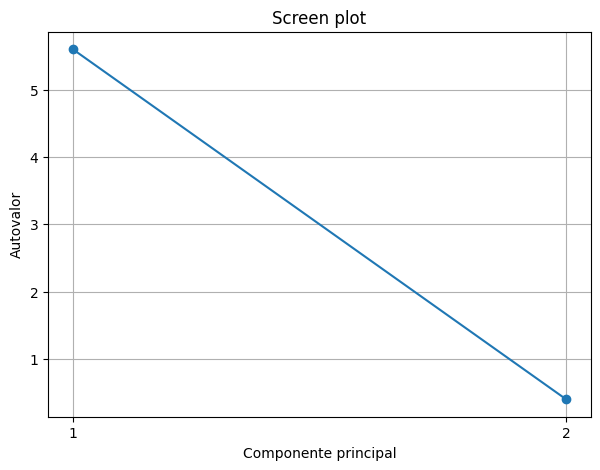

In [6]:
# @title Scree plot simple
fig, ax = plt.subplots()
ax.plot(range(1, len(eigvals)+1), eigvals, marker="o")
ax.set_xticks(range(1, len(eigvals)+1))
ax.set_xlabel("Componente principal")
ax.set_ylabel("Autovalor")
ax.set_title("Screen plot")
plt.show()

## 6. Visualización dinámica 1: efecto de la correlación en la geometría y en PCA

En la matriz

$$
\Sigma_\rho =
\begin{pmatrix}
1 & \rho \\
\rho & 1
\end{pmatrix},
$$

el parámetro $\rho$ controla la relación lineal entre las variables.

- Si $\rho = 0$, no hay inclinación preferente.
- Si $\rho > 0$, la nube se alarga cerca de la recta $x_1 = x_2$.
- Si $\rho < 0$, la nube se alarga cerca de la recta $x_1 = -x_2$.
- A medida que $|\rho|$ aumenta, la primera componente captura una fracción mayor de la varianza.

El siguiente gráfico interactivo permite ver eso con un deslizador.

In [7]:
# @title Gráfico interactivo con deslizador para rho
rhos = np.linspace(-0.9, 0.9, 100)
frames = []
annotations_per_frame = []

for rho in rhos:
    S = np.array([[1.0, rho], [rho, 1.0]])
    vals, vecs = eigh(S)
    idx = np.argsort(vals)[::-1]
    vals = vals[idx]
    vecs = vecs[:, idx]

    Xr = simular_normal([0, 0], S, n=250, seed=int((rho + 1) * 1000))

    v1 = vecs[:, 0] * 2.5 * np.sqrt(vals[0])
    v2 = vecs[:, 1] * 2.5 * np.sqrt(vals[1])

    prop1 = vals[0] / vals.sum()
    prop2 = vals[1] / vals.sum()

    frames.append(go.Frame(
        name=f"{rho:.2f}",
        data=[
            go.Scatter(x=Xr[:,0], y=Xr[:,1], mode="markers", marker=dict(size=5), name="Datos"),
            go.Scatter(x=[0, v1[0]], y=[0, v1[1]], mode="lines+text",
                       text=["", "PC1"], textposition="top center", name="PC1"),
            go.Scatter(x=[0, v2[0]], y=[0, v2[1]], mode="lines+text",
                       text=["", "PC2"], textposition="top center", name="PC2"),
        ],
        layout=go.Layout(
            title=f"rho = {rho:.2f} | Var. explicada PC1 = {prop1:.3f} | PC2 = {prop2:.3f}"
        )
    ))

fig = go.Figure(
    data=frames[0].data,
    frames=frames
)

steps = []
for rho in rhos:
    steps.append({
        "method": "animate",
        "label": f"{rho:.2f}",
        "args": [[f"{rho:.2f}"], {"mode": "immediate", "frame": {"duration": 0, "redraw": True},
                                  "transition": {"duration": 0}}]
    })

fig.update_layout(
    width=800,
    height=650,
    xaxis=dict(range=[-4, 4], scaleanchor="y", scaleratio=1, title="$X_1$"),
    yaxis=dict(range=[-4, 4], title="$X_2$"),
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "rho = "},
        "pad": {"t": 35},
        "steps": steps
    }],
    showlegend=False
)

fig.show()

### Qué debe observarse

1. La orientación de la nube cambia con $\rho$.
2. La dirección de PC1 coincide con el eje mayor de la nube.
3. Cuando $|\rho|$ aumenta, PC1 concentra más varianza.
4. Si $\rho = 0$ y las varianzas son iguales, ninguna dirección domina claramente.

Este punto es crucial: **PCA detecta estructura anisotrópica** de la nube.

## 7. De la teoría a la construcción de PCA

Supongamos que tenemos una matriz de datos

$$
X =
\begin{pmatrix}
x_{11} & \cdots & x_{1p} \\
\vdots & \ddots & \vdots \\
x_{n1} & \cdots & x_{np}
\end{pmatrix},
$$

con $n$ observaciones y $p$ variables.

### Paso 1: centrar las variables

Se resta la media de cada columna. Si el centrado produce la matriz $X_c$, entonces cada columna de $X_c$ tiene media cero.

### Paso 2: construir la matriz de covarianza muestral

$$
S = \frac{1}{n-1} X_c^T X_c.
$$

### Paso 3: descomposición espectral de $S$

Hallamos autovalores y autovectores de $S$:

$$
S = Q \Lambda Q^T.
$$

### Paso 4: ordenar de mayor a menor

Ordenamos autovalores y autovectores según la varianza explicada.

### Paso 5: construir las componentes principales

Las nuevas variables son combinaciones lineales de las variables originales:

$$
Z = X_c Q.
$$

La columna $j$ de $Z$ es la componente principal $j$.

### Interpretación

- las columnas de $Q$ son las **direcciones**,
- las columnas de $Z$ son las **coordenadas** de cada observación en esas direcciones,
- $\Lambda$ indica la varianza de cada componente.

In [8]:
# @title Ejemplo paso a paso: construcción manual de PCA en 2D
rng = np.random.default_rng(42)
A = np.array([[2.2, 1.2],
              [0.4, 1.0]])
U = rng.normal(size=(350, 2))
X2 = U @ A.T

# Paso 1: centrar
X2_mean = X2.mean(axis=0)
X2c = X2 - X2_mean

# Paso 2: covarianza muestral
S = np.cov(X2c, rowvar=False)

# Paso 3: descomposición espectral
vals, vecs = eigh(S)
idx = np.argsort(vals)[::-1]
vals = vals[idx]
vecs = vecs[:, idx]

# Paso 4: scores
Z = X2c @ vecs

print("Media original:")
print(X2_mean)

print("\nMatriz de covarianza muestral S:")
print(S)

print("\nAutovalores:")
print(vals)

print("\nAutovectores (columnas):")
print(vecs)

print("\nPrimeras 5 observaciones transformadas (scores):")
print(Z[:5])

Media original:
[-0.1094 -0.0665]

Matriz de covarianza muestral S:
[[6.9578 2.3657]
 [2.3657 1.195 ]]

Autovalores:
[7.8045 0.3483]

Autovectores (columnas):
[[-0.9415  0.337 ]
 [-0.337  -0.9415]]

Primeras 5 observaciones transformadas (scores):
[[ 0.7279  0.644 ]
 [-3.1606 -0.2572]
 [ 6.0889 -0.038 ]
 [ 0.0565  0.1908]
 [ 1.163   0.4263]]


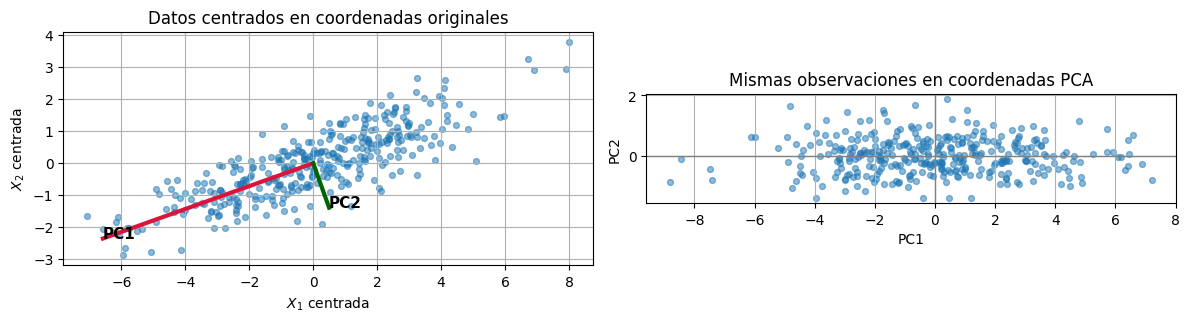

In [9]:
# @title Visualización: datos originales y datos en coordenadas principales
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(X2c[:, 0], X2c[:, 1], alpha=0.5, s=18)
dibujar_autodirecciones(axes[0], S)
axes[0].set_title("Datos centrados en coordenadas originales")
axes[0].set_xlabel("$X_1$ centrada")
axes[0].set_ylabel("$X_2$ centrada")
axes[0].set_aspect("equal")

axes[1].scatter(Z[:, 0], Z[:, 1], alpha=0.5, s=18)
axes[1].axhline(0, color="gray", lw=1)
axes[1].axvline(0, color="gray", lw=1)
axes[1].set_title("Mismas observaciones en coordenadas PCA")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

### Qué ocurrió en el cambio de coordenadas

No cambiamos los datos en esencia; cambiamos el sistema de referencia.

- En el sistema original, las variables pueden estar correlacionadas.
- En el sistema PCA, las componentes están alineadas con las direcciones de mayor y menor varianza.
- La covarianza entre componentes principales es cero.

En otras palabras, PCA realiza una **rotación ortogonal** del sistema de coordenadas después del centrado.

In [10]:
# @title Verificación: covarianza de los scores
np.cov(Z, rowvar=False)

array([[7.8045, 0.    ],
       [0.    , 0.3483]])

La matriz anterior debe ser diagonal, salvo error numérico. En particular,

$$
\mathrm{Cov}(Z) = \Lambda.
$$

Esto muestra que las componentes principales quedan no correlacionadas y que sus varianzas son exactamente los autovalores.

## 8. Cargas, scores y reconstrucción

En PCA aparecen tres objetos que conviene distinguir con claridad.

### 8.1. Cargas

Las **cargas** son los coeficientes de los autovectores. Indican cómo se construye cada componente a partir de las variables originales.

Si

$$
q_1 =
\begin{pmatrix}
0.8 \\
0.6
\end{pmatrix},
$$

entonces

$$
\mathrm{PC1} = 0.8 X_1^{(c)} + 0.6 X_2^{(c)}.
$$

### 8.2. Scores

Los **scores** son los valores de las observaciones sobre las nuevas componentes. Se calculan como

$$
Z = X_c Q.
$$

### 8.3. Reconstrucción con pocas componentes

Si solo conservamos las primeras $k$ componentes, con $Q_k$ formado por los primeros $k$ autovectores, la aproximación de rango $k$ es

$$
\hat X^{(k)} = Z_k Q_k^T = X_c Q_k Q_k^T.
$$

Esto permite reducir dimensión conservando la estructura principal.

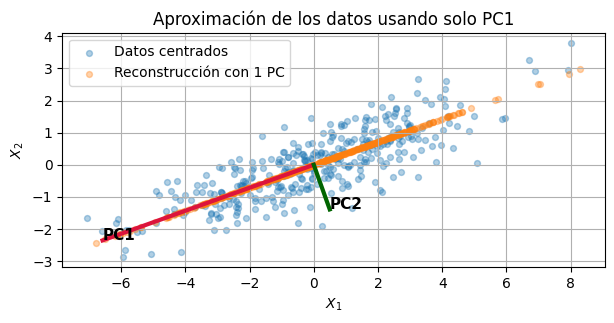

In [11]:
# @title Reconstrucción con 1 componente en el ejemplo 2D
Q1 = vecs[:, :1]
Z1 = X2c @ Q1
X2_recon_1 = Z1 @ Q1.T

fig, ax = plt.subplots()
ax.scatter(X2c[:, 0], X2c[:, 1], alpha=0.35, s=18, label="Datos centrados")
ax.scatter(X2_recon_1[:, 0], X2_recon_1[:, 1], alpha=0.35, s=18, label="Reconstrucción con 1 PC")
dibujar_autodirecciones(ax, S)
ax.set_title("Aproximación de los datos usando solo PC1")
ax.set_xlabel("$X_1$")
ax.set_ylabel("$X_2$")
ax.legend()
ax.set_aspect("equal")
plt.show()

### Interpretación

Al conservar solo PC1:

- cada punto se proyecta sobre la recta generada por la primera dirección principal,
- se pierde la variación asociada a PC2,
- pero se conserva la parte dominante de la estructura si PC1 explica gran parte de la varianza.

Esta es la lógica de la reducción de dimensión por PCA.

## 9. Visualización dinámica 2: reconstrucción al retener más componentes

Ahora construiremos un ejemplo en dimensión 3. La idea es ver cómo mejora la reconstrucción al conservar:

- solo PC1,
- PC1 y PC2,
- las tres componentes.

El deslizador permite comparar el efecto de $k$.

In [12]:
# @title Simulación 3D y reconstrucción con deslizador
rng = np.random.default_rng(123)
B = np.array([
    [2.0, 0.8, 0.2],
    [0.2, 1.3, 0.4],
    [0.1, 0.3, 0.5]
])
X3 = rng.normal(size=(220, 3)) @ B.T
X3c = X3 - X3.mean(axis=0)

S3 = np.cov(X3c, rowvar=False)
vals3, vecs3 = eigh(S3)
idx = np.argsort(vals3)[::-1]
vals3 = vals3[idx]
vecs3 = vecs3[:, idx]

frames = []
for k in [1, 2, 3]:
    Qk = vecs3[:, :k]
    Zk = X3c @ Qk
    Xhat = Zk @ Qk.T
    err = np.mean(np.sum((X3c - Xhat)**2, axis=1))

    frames.append(go.Frame(
        name=str(k),
        data=[
            go.Scatter3d(
                x=X3c[:,0], y=X3c[:,1], z=X3c[:,2],
                mode="markers", marker=dict(size=3), name="Original"
            ),
            go.Scatter3d(
                x=Xhat[:,0], y=Xhat[:,1], z=Xhat[:,2],
                mode="markers", marker=dict(size=3), name="Reconstrucción"
            )
        ],
        layout=go.Layout(
            title=f"Reconstrucción con k = {k} componente(s) | Error medio cuadrático = {err:.4f}"
        )
    ))

fig3 = go.Figure(data=frames[0].data, frames=frames)

steps = []
for k in [1, 2, 3]:
    steps.append({
        "method": "animate",
        "label": str(k),
        "args": [[str(k)], {"mode": "immediate", "frame": {"duration": 0, "redraw": True},
                            "transition": {"duration": 0}}]
    })

fig3.update_layout(
    width=850,
    height=700,
    scene=dict(
        xaxis_title="X1",
        yaxis_title="X2",
        zaxis_title="X3"
    ),
    sliders=[{
        "active": 0,
        "currentvalue": {"prefix": "Número de componentes retenidas: "},
        "pad": {"t": 35},
        "steps": steps
    }]
)

fig3.show()

### Lectura de la visualización

- Con $k=1$, la reconstrucción es muy tosca: todo queda cerca de una recta.
- Con $k=2$, aparece un plano que recoge mucha más estructura.
- Con $k=3$, recuperamos exactamente el conjunto centrado.

Esta es una forma geométrica muy clara de entender la reducción de dimensión.

## 10. PCA usando covarianza o correlación

Hasta ahora hemos trabajado con la matriz de covarianza. Sin embargo, en práctica hay dos enfoques:

### PCA sobre covarianza
Se usa cuando:
- las variables están en escalas comparables,
- la magnitud absoluta de la varianza es informativa.

### PCA sobre correlación
Se usa cuando:
- las variables tienen unidades muy distintas,
- una variable con escala grande podría dominar artificialmente el análisis.

En ese caso se estandarizan las variables y se hace PCA sobre la matriz de correlación.

**Regla práctica:** si una variable está en pesos, otra en centímetros y otra en proporciones, normalmente conviene estandarizar.

In [13]:
# @title Ejemplo: efecto de la estandarización
rng = np.random.default_rng(7)

x1 = rng.normal(0, 1, 300)
x2 = 5 * x1 + rng.normal(0, 2, 300)
x3 = 100 * x1 + rng.normal(0, 20, 300)  # escala mucho mayor

df = pd.DataFrame({"x1": x1, "x2": x2, "x3": x3})

# PCA sobre covarianza
pca_cov = PCA()
pca_cov.fit(df)

# PCA sobre correlación (variables estandarizadas)
scaler = StandardScaler()
df_std = scaler.fit_transform(df)

pca_cor = PCA()
pca_cor.fit(df_std)

comparacion = pd.DataFrame({
    "Componente": ["PC1", "PC2", "PC3"],
    "VarExp_cov": pca_cov.explained_variance_ratio_,
    "VarExp_cor": pca_cor.explained_variance_ratio_
})

comparacion

,Componente,VarExp_cov,VarExp_cor
0,PC1,0.999501,0.958476
1,PC2,0.000495,0.034597
2,PC3,0.000004,0.006927


### Comentario

Si una variable tiene una escala mucho mayor, PCA sobre covarianza puede concentrarse excesivamente en ella. Al estandarizar, todas las variables parten con varianza 1 y el análisis se enfoca más en la estructura relacional que en la escala.

## 11. Construcción completa de PCA con un ejemplo más realista

Ahora construiremos un ejemplo en dimensión 4, donde las variables tienen dependencia interna. Haremos:

1. centrado,
2. covarianza,
3. autovalores y autovectores,
4. varianza explicada,
5. selección del número de componentes,
6. transformación de los datos.

In [14]:
# @title Ejemplo 4D paso a paso
rng = np.random.default_rng(2026)
n = 500

z1 = rng.normal(size=n)
z2 = rng.normal(size=n)
z3 = rng.normal(size=n)

x1 = 2.5*z1 + 0.2*z2 + rng.normal(scale=0.3, size=n)
x2 = 2.0*z1 - 0.1*z2 + rng.normal(scale=0.4, size=n)
x3 = 1.8*z2 + 0.2*z3 + rng.normal(scale=0.35, size=n)
x4 = 0.3*z1 + 0.2*z2 + 0.8*z3 + rng.normal(scale=0.5, size=n)

X4 = np.column_stack([x1, x2, x3, x4])
X4c = X4 - X4.mean(axis=0)

S4 = np.cov(X4c, rowvar=False)
vals4, vecs4 = eigh(S4)
idx = np.argsort(vals4)[::-1]
vals4 = vals4[idx]
vecs4 = vecs4[:, idx]

prop4 = vals4 / vals4.sum()
acum4 = np.cumsum(prop4)

tabla4 = pd.DataFrame({
    "Componente": [f"PC{j}" for j in range(1, 5)],
    "Autovalor": vals4,
    "Proporción explicada": prop4,
    "Proporción acumulada": acum4
})

tabla4

,Componente,Autovalor,Proporción explicada,Proporción acumulada
0,PC1,11.655681,0.715857,0.715857
1,PC2,3.714662,0.228143,0.944001
2,PC3,0.777047,0.047724,0.991725
3,PC4,0.134743,0.008275,1.000000


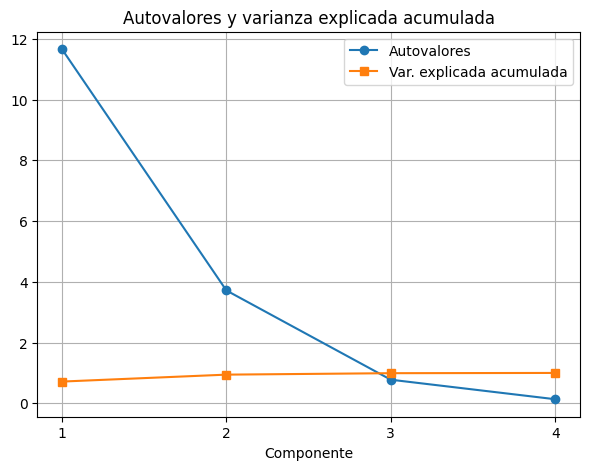

In [15]:
# @title Scree plot y varianza explicada acumulada
fig, ax = plt.subplots()
ax.plot(range(1, 5), vals4, marker="o", label="Autovalores")
ax.plot(range(1, 5), acum4, marker="s", label="Var. explicada acumulada")
ax.set_xticks(range(1, 5))
ax.set_xlabel("Componente")
ax.set_title("Autovalores y varianza explicada acumulada")
ax.legend()
plt.show()

In [16]:
# @title Cargas de las componentes
loadings = pd.DataFrame(
    vecs4,
    index=["x1", "x2", "x3", "x4"],
    columns=[f"PC{j}" for j in range(1, 5)]
)
loadings

,PC1,PC2,PC3,PC4
x1,-0.773758,0.027675,-0.124246,-0.620561
x2,-0.624120,-0.118712,0.003246,0.772251
x3,-0.033357,0.973034,-0.191987,0.123425
x4,-0.103251,0.195824,0.973496,-0.057435


### Cómo leer las cargas

Cada columna muestra cómo se combina cada componente.

Por ejemplo, si PC1 tiene cargas altas en $x_1$ y $x_2$, eso sugiere que resume la variación común de esas dos variables. Si PC2 carga sobre $x_3$, entonces está capturando otro eje estructural distinto.

Las cargas no son "importancias causales"; son coeficientes geométricos de una rotación lineal.

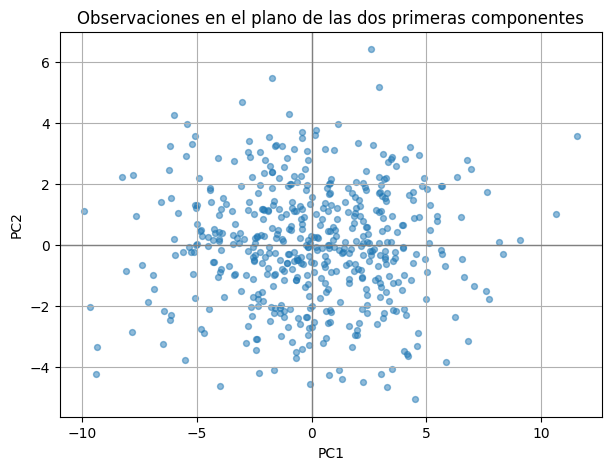

In [17]:
# @title Scores en las dos primeras componentes
Z4 = X4c @ vecs4

fig, ax = plt.subplots()
ax.scatter(Z4[:, 0], Z4[:, 1], alpha=0.5, s=18)
ax.axhline(0, color="gray", lw=1)
ax.axvline(0, color="gray", lw=1)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Observaciones en el plano de las dos primeras componentes")
plt.show()

## 12. Verificación con `sklearn`

Es útil mostrar que la construcción manual coincide con una implementación estándar.

In [18]:
# @title Comparación entre PCA manual y sklearn
pca = PCA()
pca.fit(X4c)

comparacion_pca = pd.DataFrame({
    "Autovalor_manual": vals4,
    "Autovalor_sklearn": pca.explained_variance_,
    "VarExp_manual": prop4,
    "VarExp_sklearn": pca.explained_variance_ratio_
})

comparacion_pca

,Autovalor_manual,Autovalor_sklearn,VarExp_manual,VarExp_sklearn
0,11.655681,11.655681,0.715857,0.715857
1,3.714662,3.714662,0.228143,0.228143
2,0.777047,0.777047,0.047724,0.047724
3,0.134743,0.134743,0.008275,0.008275


Las posibles diferencias de signo en los autovectores no son problema: si $q$ es autovector, también lo es $-q$. La dirección geométrica es la misma.

## 13. Resumen conceptual de PCA

PCA puede entenderse de tres formas al mismo tiempo:

### 13.1. Como problema de optimización
Busca la dirección que maximiza la varianza proyectada.

### 13.2. Como cambio de base ortogonal
Reexpresa los datos en una base formada por autovectores de la covarianza.

### 13.3. Como método de reducción de dimensión
Conserva solo las primeras componentes, que contienen la mayor parte de la variabilidad total.

## Fórmulas clave

Si $X_c$ es la matriz de datos centrada y

$$
S = \frac{1}{n-1} X_c^T X_c = Q \Lambda Q^T,
$$

entonces:

- **scores:** $$Z = X_c Q,$$
- **varianza de las componentes:** $$\mathrm{Cov}(Z) = \Lambda,$$
- **proporción explicada por PC$j$:** $$\lambda_j / \sum_k \lambda_k,$$
- **reconstrucción con $k$ componentes:** $$\hat X^{(k)} = X_c Q_k Q_k^T.$$

## 14. Errores conceptuales frecuentes

### Error 1
Creer que PCA "selecciona variables".

No. PCA construye **nuevas variables** como combinaciones lineales de las originales.

### Error 2
Creer que mayor carga implica causalidad.

No. Las cargas describen orientación geométrica, no causalidad.

### Error 3
Aplicar PCA sin pensar en la escala.

Si las variables están en unidades muy diferentes, hacer PCA sobre covarianza puede ser engañoso.

### Error 4
Creer que conservar mucha varianza garantiza utilidad predictiva.

PCA preserva estructura de variabilidad, no necesariamente la variable respuesta de un problema supervisado.

### Error 5
Interpretar automáticamente cada componente.

A veces una componente es fácilmente interpretable; otras veces solo resume una combinación matemática útil.

## 15. Ejercicios para resolver en clase

### Ejercicio 1. Descomposición espectral manual
Considere

$$
S =
\begin{pmatrix}
5 & 2 \\
2 & 2
\end{pmatrix}.
$$

1. Halle los autovalores.
2. Halle autovectores asociados.
3. Ordene de mayor a menor.
4. Calcule la proporción de varianza explicada por cada componente.
5. Interprete geométricamente cuál sería la dirección principal.

---

### Ejercicio 2. Máxima varianza proyectada
Sea $a = (a_1,a_2)^T$ con $a^T a = 1$ y

$$
\Sigma =
\begin{pmatrix}
3 & 1 \\
1 & 2
\end{pmatrix}.
$$

1. Escriba explícitamente $a^T \Sigma a$.
2. Explique por qué maximizar esa cantidad equivale a buscar la primera dirección principal.
3. Verifique que la solución corresponde a un autovector del mayor autovalor.

---

### Ejercicio 3. PCA en Python sobre datos simulados
Simule una muestra bivariada normal con media cero y covarianza

$$
\Sigma =
\begin{pmatrix}
4 & 3 \\
3 & 4
\end{pmatrix}.
$$

1. Centre los datos.
2. Calcule la matriz de covarianza muestral.
3. Obtenga autovalores y autovectores.
4. Grafique la nube y dibuje PC1 y PC2.
5. Calcule la varianza explicada.

---

### Ejercicio 4. Covarianza vs correlación
Construya un conjunto de datos con tres variables, una de ellas en una escala mucho mayor que las otras dos.

1. Haga PCA sobre la matriz de covarianza.
2. Haga PCA sobre datos estandarizados.
3. Compare las proporciones de varianza explicada.
4. Explique cuál enfoque parece más razonable y por qué.

---

### Ejercicio 5. Reconstrucción con reducción de dimensión
Con un conjunto de datos en dimensión 3 o 4:

1. Ajuste PCA.
2. Reconstruya los datos usando solo una componente.
3. Reconstruya usando dos componentes.
4. Compare visual o numéricamente el error de reconstrucción.
5. Explique la relación entre número de componentes retenidas y pérdida de información.

---

### Ejercicio 6. Interpretación de cargas
Suponga que, en un PCA con cuatro variables, las cargas de PC1 son aproximadamente

$$
(0.70,\ 0.68,\ 0.20,\ 0.10)^T.
$$

y las de PC2 son

$$
(0.05,\ 0.10,\ 0.72,\ 0.68)^T.
$$

Explique, sin hacer cálculos complejos:

1. qué variables dominan PC1,
2. qué variables dominan PC2,
3. qué tipo de estructura parece estar resumiendo cada componente.

---

### Ejercicio 7. Pregunta conceptual final
Explique con sus propias palabras la diferencia entre:

- autovectores de una matriz de covarianza,
- direcciones principales,
- scores,
- cargas,
- varianza explicada.

La explicación debe distinguir claramente el papel de cada objeto.

## 16. Mini guía de cierre para la clase

Al terminar esta sesión, el estudiante debería poder responder con claridad a estas preguntas:

1. ¿Por qué una matriz de covarianza tiene autovalores no negativos?
2. ¿Por qué la primera componente principal maximiza varianza proyectada?
3. ¿Qué representan geométricamente los autovectores?
4. ¿Qué diferencia hay entre cargas y scores?
5. ¿Cuándo usar PCA sobre covarianza y cuándo sobre correlación?
6. ¿Qué se gana y qué se pierde al conservar solo $k$ componentes?

Si estas seis ideas quedan claras, entonces la base conceptual de PCA queda bien construida.